# Análisis Exploratorio de Datos (EDA)

## Proyecto: Clasificación de Pacientes GES en Chile

### Objetivo

Este análisis exploratorio busca comprender la estructura del conjunto de datos de derivaciones médicas utilizado para identificar pacientes cubiertos por el sistema GES (Garantías Explícitas en Salud).

El propósito de este EDA es:

- Conocer la calidad de los datos.
- Detectar posibles problemas de limpieza.
- Explorar la distribución de edades.
- Analizar la proporción de casos GES y No GES.
- Identificar los diagnósticos más frecuentes.
- Obtener información útil para el análisis posterior.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px

df = pd.read_csv("../data/dataset_original.csv")

df.head()

,id,diagnostic,age,ges
0,1,RAQUIESTENOSIS L4-L5 Y DISCOPATIA SEVERA L5-S1,67,False
1,10,ABSCESO OVARICO,50,False
2,100,Cálculo del uréter,57,False
3,101,Cálculo del uréter,28,False
4,102,Cálculo del uréter,54,False


# 1. Inspección Inicial del Dataset

En esta sección revisamos la estructura general del conjunto de datos para conocer la cantidad de registros, variables disponibles y tipos de datos.

In [3]:
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

df.info()

Filas: 941
Columnas: 4
<class 'pandas.DataFrame'>
RangeIndex: 941 entries, 0 to 940
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   id          941 non-null    int64
 1   diagnostic  941 non-null    str  
 2   age         941 non-null    int64
 3   ges         941 non-null    bool 
dtypes: bool(1), int64(2), str(1)
memory usage: 41.2 KB


In [4]:
df.describe()

,id,age
count,941.000000,941.000000
mean,471.000000,50.448459
std,271.787601,22.900960
min,1.000000,0.000000
25%,236.000000,33.000000
50%,471.000000,56.000000
75%,706.000000,67.000000
max,941.000000,99.000000


# 2. Valores Nulos

Los valores faltantes pueden afectar los análisis y modelos posteriores.

Verificaremos si existen datos incompletos en las variables del dataset.

In [5]:
df.isnull().sum()

id            0
diagnostic    0
age           0
ges           0
dtype: int64

# 3. Distribución de la Edad

La edad es una de las variables disponibles en el dataset.

Analizaremos cómo se distribuyen las edades de los pacientes para detectar posibles concentraciones o valores atípicos.

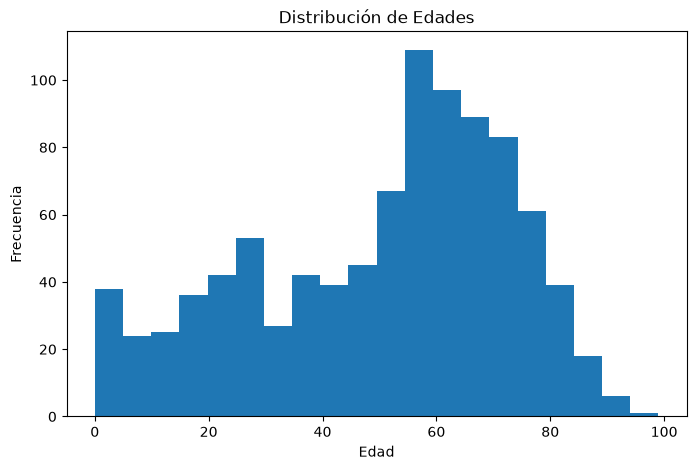

In [6]:
plt.figure(figsize=(8,5))

plt.hist(df["age"], bins=20)

plt.title("Distribución de Edades")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")

plt.show()

### Interpretación

Este gráfico permite observar los rangos de edad más frecuentes en las derivaciones médicas registradas.

La distribución puede ayudar a identificar si existen grupos etarios con mayor presencia dentro del sistema.

# 4. Distribución de Casos GES

La variable objetivo del proyecto es `ges`.

Analizaremos la cantidad de registros clasificados como GES y No GES.

In [7]:
fig = px.histogram(
    df,
    x="ges",
    title="Distribución de Casos GES"
)

fig.show()

df["ges"].value_counts()

# 5. Edad según Clasificación GES

Se analizará si existen diferencias en la distribución de edades entre pacientes clasificados como GES y No GES.

In [8]:
fig = px.box(
    df,
    x="ges",
    y="age",
    title="Edad según Clasificación GES"
)

fig.show()

### Interpretación

El diagrama de caja permite comparar la mediana, dispersión y presencia de valores extremos entre ambos grupos.

# 6. Diagnósticos Más Frecuentes

Dado que el diagnóstico médico es la variable principal del proyecto, resulta relevante identificar cuáles son los diagnósticos más comunes.

In [9]:
top_diag = (
    df["diagnostic"]
    .value_counts()
    .head(10)
)

top_diag

diagnostic
COLELITIASIS                       38
CATARATA OI                        20
CATARATA OD                        19
CATARATA ODI SAN JOSE              18
CBC                                17
CX DE TERCEROS MOLARES             16
FIMOSIS                            14
Cálculo del uréter                 11
CATARATA OI SAN JOSE               11
Hiperplasia de la Próstata  HPB    11
Name: count, dtype: int64

In [10]:
fig = px.bar(
    top_diag,
    title="Top 10 Diagnósticos Más Frecuentes"
)

fig.show()

### Interpretación

Los diagnósticos más frecuentes pueden influir significativamente en los resultados del modelo de clasificación y permiten comprender mejor el contexto clínico del dataset.

# 7. Heatmap de Correlación

Aunque el dataset posee pocas variables numéricas, es útil visualizar posibles relaciones entre ellas.

Para ello convertiremos la variable GES a formato numérico.

In [11]:
df_corr = df.copy()

df_corr["ges_num"] = (
    df_corr["ges"]
    .astype(int)
)

corr = df_corr[
    ["age", "ges_num"]
].corr()

corr

,age,ges_num
age,1.000000,0.326686
ges_num,0.326686,1.000000


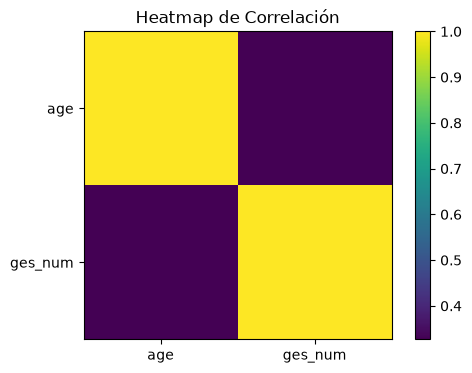

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.imshow(corr)

plt.xticks(
    range(len(corr.columns)),
    corr.columns
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.colorbar()

plt.title("Heatmap de Correlación")

plt.show()

### Interpretación

El mapa de calor permite identificar si existe una relación lineal entre la edad y la clasificación GES.

Valores cercanos a 1 indican correlación positiva fuerte, mientras que valores cercanos a 0 indican poca relación lineal.

# Conclusiones del EDA

Principales hallazgos:

- El dataset contiene 941 registros.
- La variable objetivo corresponde a la clasificación GES.
- La edad presenta una distribución amplia entre los pacientes.
- Existen diagnósticos que aparecen con mucha mayor frecuencia que otros.
- La correlación entre edad y clasificación GES es limitada, lo que sugiere que el diagnóstico médico probablemente tenga un rol más importante en la predicción.

Este análisis exploratorio servirá como base para las etapas de limpieza, modelamiento y construcción del dashboard interactivo.